In [1]:
import pickle
from tools import *

features_path = './data/features'
returns_path = './data'
output_path = './output'

# 非基本面
with open(f'{returns_path}/monthly_returns.pkl', 'rb') as f:
    ret = pickle.load(f)
with open(f'{features_path}/mcap.pkl', 'rb') as f:
    df = pickle.load(f)
    df.fillna(df.median(axis=1), axis=0)
    mcap = xs_zscore(df)
with open(f'{features_path}/amount_21.pkl', 'rb') as f:
    df = pickle.load(f)
    df.fillna(df.median(axis=1), axis=0)
    amt = xs_zscore(df)
with open(f'{features_path}/turnover_252.pkl', 'rb') as f:
    df = pickle.load(f)
    df.fillna(df.median(axis=1), axis=0)
    turn = xs_zscore(df)
with open(f'{features_path}/momentum_21.pkl', 'rb') as f:
    df = pickle.load(f)
    df.fillna(df.median(axis=1), axis=0)
    mom = xs_zscore(df)

# 盈利
with open(f'{features_path}/operating_profit_to_book_value_ttm.pkl', 'rb') as f:
    df = pickle.load(f)
    df.fillna(df.median(axis=1), axis=0)
    roe = xs_zscore(df)
with open(f'{features_path}/accrual_to_net_profit_ttm.pkl', 'rb') as f:
    df = pickle.load(f)
    df.fillna(df.median(axis=1), axis=0)
    atn = xs_zscore(df)


# 估值
with open(f'{features_path}/book_value_mrq.pkl', 'rb') as f:
    df = pickle.load(f)
    df.fillna(df.median(axis=1), axis=0)
    book = xs_zscore(df)
with open(f'{features_path}/basic_eps_mra.pkl', 'rb') as f:
    df = pickle.load(f)
    df.fillna(df.median(axis=1), axis=0)
    eps = xs_zscore(df)

# 投资/增长
with open(f'{features_path}/asset_growth_mrq.pkl', 'rb') as f:
    df = pickle.load(f)
    df.fillna(df.median(axis=1), axis=0)
    ast_grth = xs_zscore(df)

with open(f'{features_path}/capital_gain_overhang_252.pkl', 'rb') as f:
    df = pickle.load(f)
    df.fillna(df.median(axis=1), axis=0)
    cap_gain = xs_zscore(df)

with open(f'{features_path}/change_in_net_operating_assets.pkl', 'rb') as f:
    df = pickle.load(f)
    df.fillna(df.median(axis=1), axis=0)
    op_ast_cng = xs_zscore(df)


C:\Users\jason\AppData\Local\Temp\ipykernel_35144\112965202.py:10: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  ret = pickle.load(f)
C:\Users\jason\AppData\Local\Temp\ipykernel_35144\112965202.py:12: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functi

In [2]:
# 计算因子
market_return = ret.mean(axis=1)
f_mkt = ret.apply(lambda x: market_return, axis=0)

In [3]:
f_list = [
    roe,atn,
    book,eps,
    ast_grth,cap_gain,op_ast_cng]

unf_list = [f_mkt,mcap,mom,amt,turn]
all_list = f_list + unf_list

pre_sample = ('2014-01-01', '2015-12-31')
in_sample = ('2016-01-01', '2021-12-31')
post_sample = ('2022-01-01', '2023-12-31')
all_sample = ('2014-01-01', '2023-12-31')

ret = ret.loc[all_sample[0]:all_sample[1]]
for i in range(len(f_list)):
    f_list[i] = f_list[i].loc[all_sample[0]:all_sample[1]]
for i in range(len(unf_list)):
    unf_list[i] = unf_list[i].loc[all_sample[0]:all_sample[1]]

Training MLP model with IC loss...
Epoch 1/5
6117/6117 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.9223 - mse: 0.2091 - val_loss: 0.9512 - val_mse: 0.1861
Epoch 2/5
6117/6117 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 0.8765 - mse: 0.2294 - val_loss: 0.9632 - val_mse: 0.2782
Epoch 3/5
6117/6117 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - loss: 0.8608 - mse: 0.2840 - val_loss: 0.9638 - val_mse: 0.2594
Epoch 4/5
6117/6117 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - loss: 0.8487 - mse: 0.2366 - val_loss: 0.9583 - val_mse: 0.1517
Epoch 5/5
6117/6117 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - loss: 0.8369 - mse: 0.1644 - val_loss: 0.9636 - val_mse: 0.1498
MLP Model Training R² Score: -11.1836
Predicting returns...


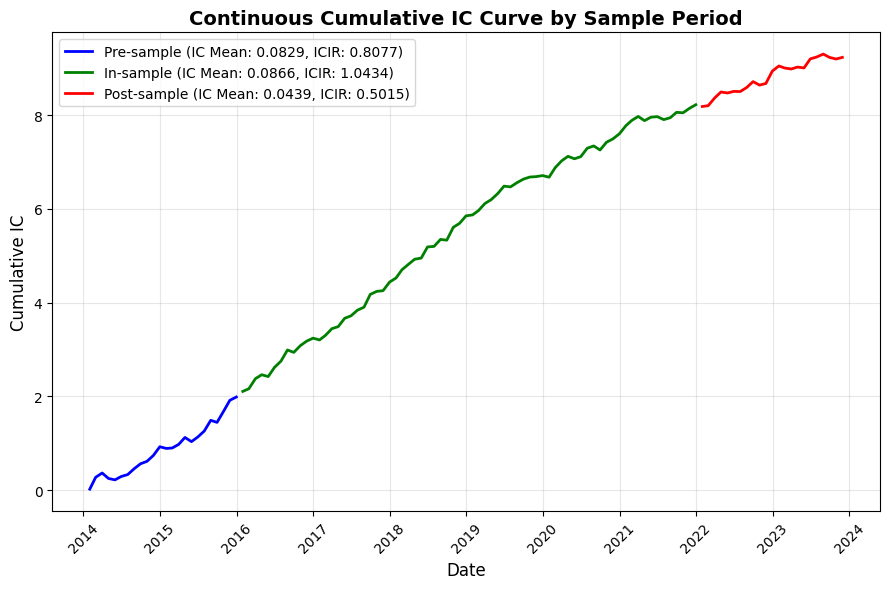

In [4]:
# 单步预测
next_period = train_outter_mlp_model(
    ret, all_list,in_sample,
    epochs = 5,
    hidden_layer_sizes=(20, 25, 20),
    activation='relu',
    alpha=0.01,
    loss_function='IC'
)
ret_hat = mlp_predict_returns(next_period, all_list, all_sample)
ret_hat.to_csv(f'{output_path}/baseline.csv')
ic_stats = calculate_ic_analysis(ret_hat, ret.shift(-1), pre_sample, in_sample, post_sample)

inner
训练数据形状: X=(216356, 7), y=(216356, 7)
Training inner MLP model with MSE loss...
Epoch 1/4
6085/6085 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 0.3784 - mse: 0.3784 - val_loss: 0.3891 - val_mse: 0.3891
Epoch 2/4
6085/6085 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 0.2839 - mse: 0.2839 - val_loss: 0.3827 - val_mse: 0.3827
Epoch 3/4
6085/6085 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.2793 - mse: 0.2793 - val_loss: 0.3788 - val_mse: 0.3788
Epoch 4/4
6085/6085 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 0.2774 - mse: 0.2774 - val_loss: 0.3787 - val_mse: 0.3787
多输出MLP模型训练R² Score: 0.6970
ourter
Training MLP model with IC loss...
Epoch 1/5
6117/6117 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 0.9220 - mse: 0.1715 - val_loss: 0.9430 - val_mse: 0.0943
Epoch 2/5
6117/6117 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 0.8786 - mse: 0.1128 - val_loss: 0.9461 - val_mse: 0.1362
Epoch 3/5
6117/6117 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.8621 - mse: 0.1240 - val_loss: 0.9615 - val_mse: 0.0994
Epoch 4

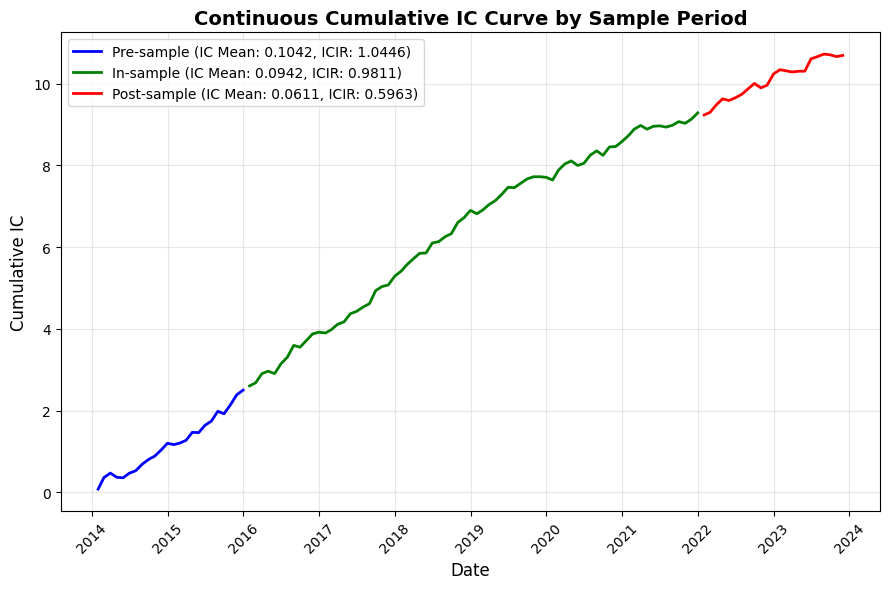

In [5]:
# 两步预测
print('inner')
inner_mlp = train_inner_mlp_model(
    f_list, in_sample,
    epochs = 4,
    hidden_layer_sizes=(10,20,10), 
    activation='relu', 
    alpha=0.01)

f_list_hat = inner_mlp_predict_returns(inner_mlp, f_list, all_sample)

print('ourter')
next_period = train_outter_mlp_model(
    ret, f_list_hat + unf_list, in_sample,
    epochs = 5,
    hidden_layer_sizes = (20, 25, 20),
    activation='relu',
    alpha=0.01,
    loss_function='IC'
)
ret_hat = mlp_predict_returns(next_period, f_list_hat + unf_list, all_sample)
ret_hat.to_csv(f'{output_path}/twostage.csv')
ic_stats = calculate_ic_analysis(ret_hat, ret.shift(-1), pre_sample, in_sample, post_sample)